In [ ]:
#importing all requried libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#data preprocesing

In [ ]:
df=pd.read_csv('ai4i2020.csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [ ]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [ ]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
df['Machine failure'].value_counts()
df['Machine failure'].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [ ]:
df['Machine failure'].value_counts()


Machine failure
0    9661
1     339
Name: count, dtype: int64

In [ ]:
#EDA

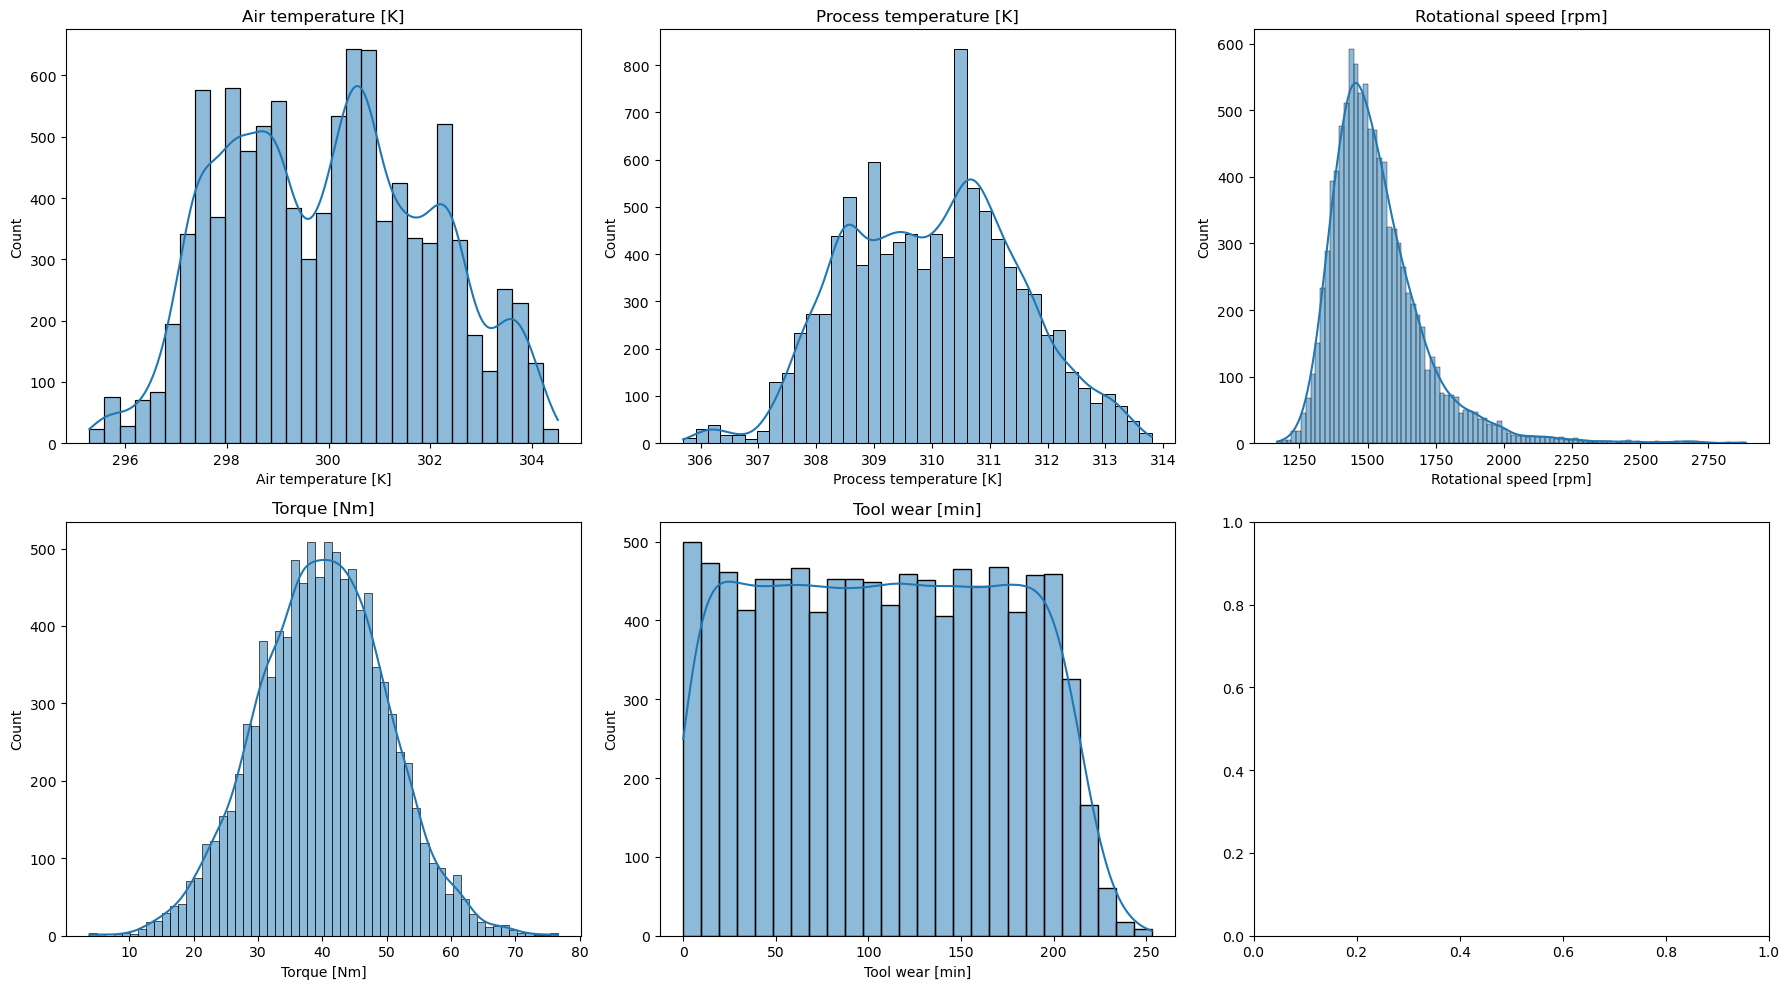

In [ ]:
#Numerical feature distributions
num_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

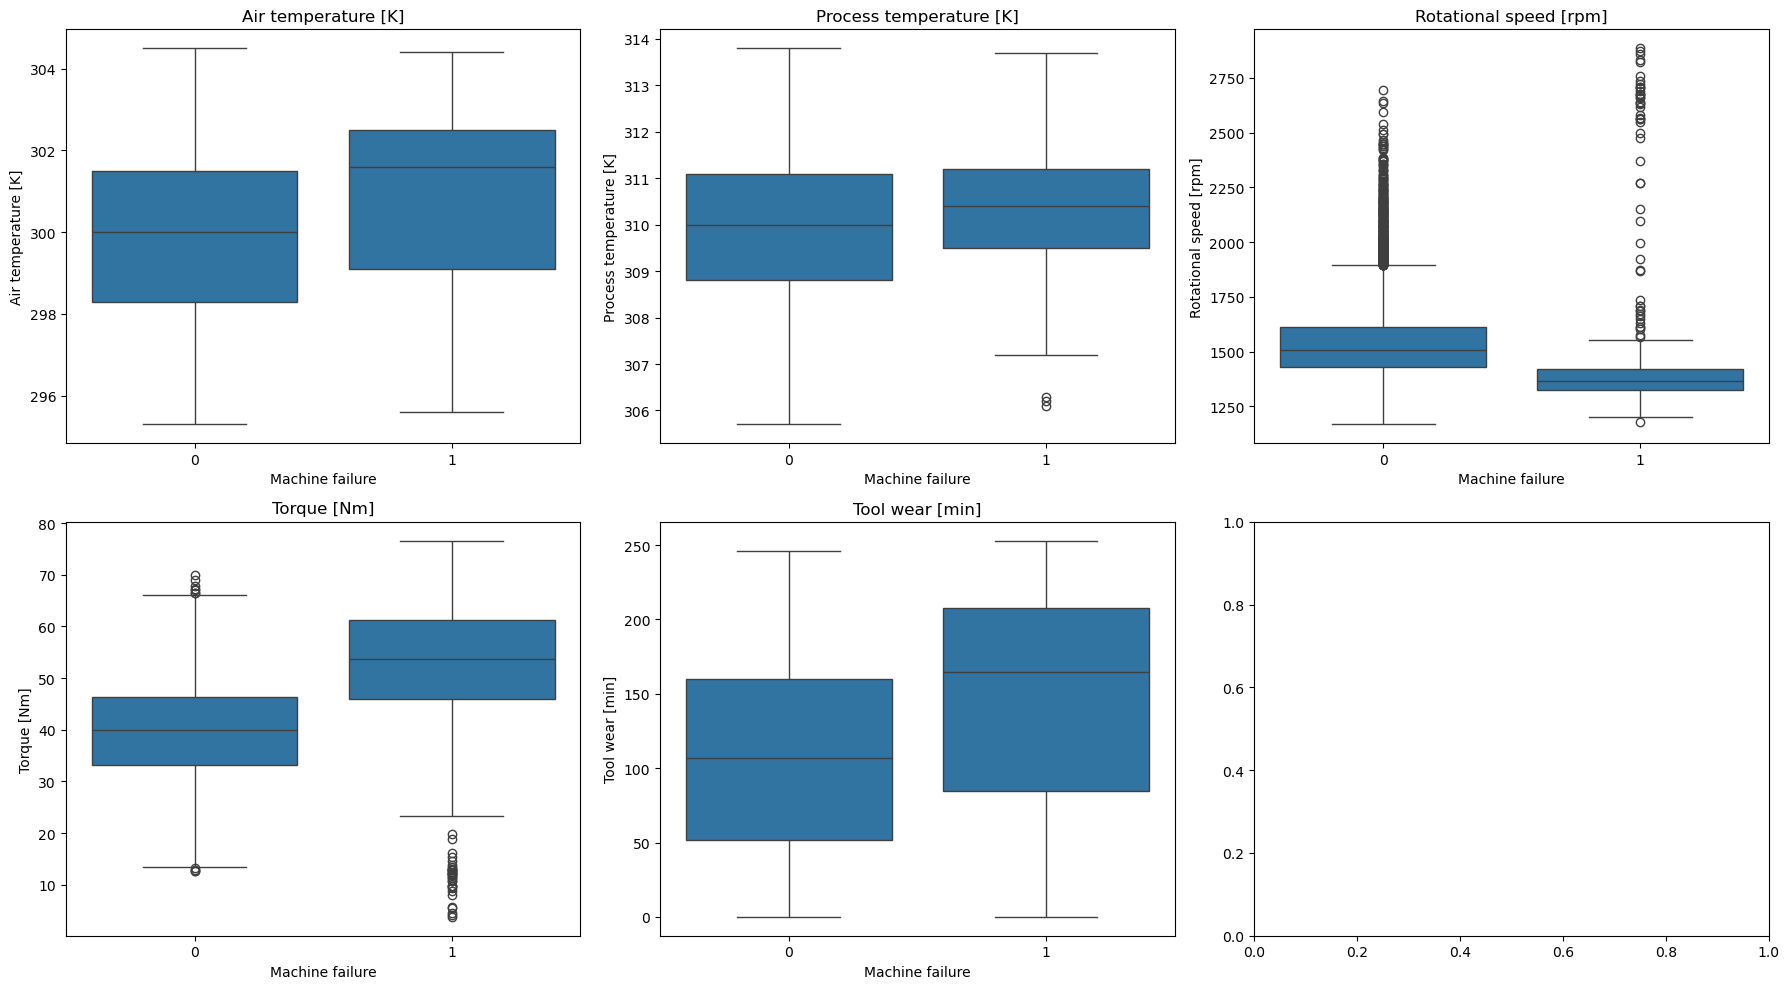

In [ ]:
#Feature distributions split by failure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Machine failure', y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

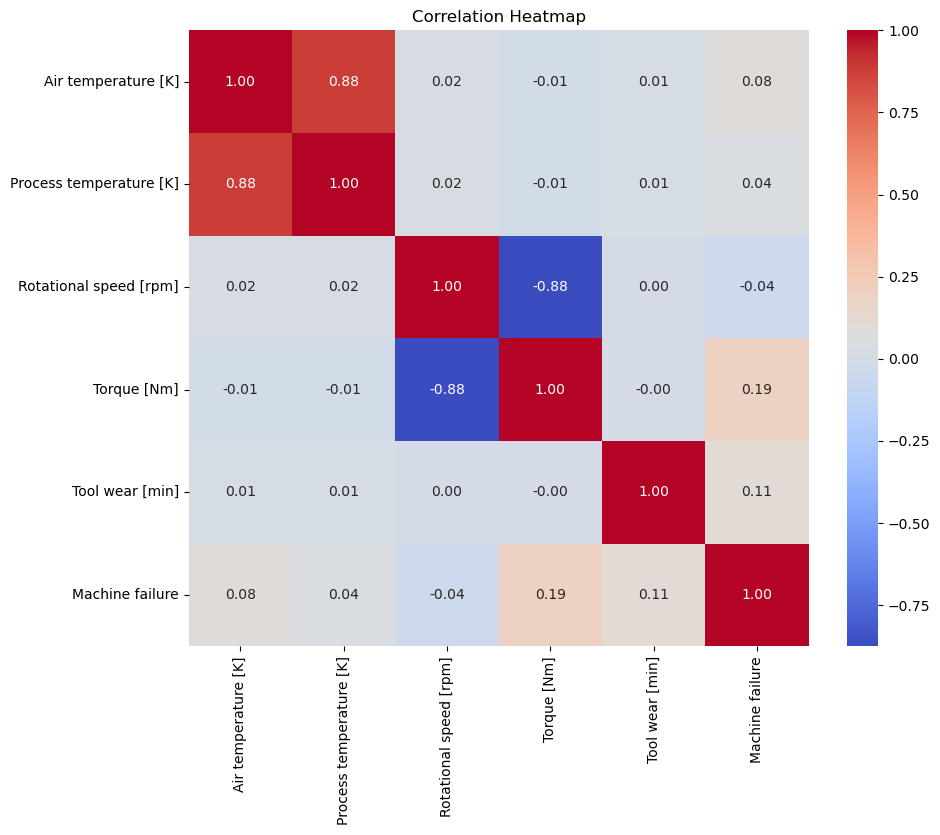

In [ ]:
#Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[num_cols + ['Machine failure']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#Categorical feature (Type) vs failure
print(df['Type'].value_counts())
print()
print(df.groupby('Type')['Machine failure'].mean())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Type
H    0.020937
L    0.039167
M    0.027694
Name: Machine failure, dtype: float64


In [ ]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df[failure_modes].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [ ]:
#data cleaning  And Feature Engineering
data = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])

data['Temp_diff'] = data['Process temperature [K]'] - data['Air temperature [K]']
data['Power'] = data['Torque [Nm]'] * (data['Rotational speed [rpm]'] * 2 * np.pi / 60)
data['Torque_per_wear'] = data['Torque [Nm]'] / (data['Tool wear [min]'] + 1)
data = pd.get_dummies(data, columns=['Type'], drop_first=True)
data['Type_L'] = data['Type_L'].astype(int)
data['Type_M'] = data['Type_M'].astype(int)

print(data.columns.tolist())
data.head()

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Temp_diff', 'Power', 'Torque_per_wear', 'Type_L', 'Type_M']


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_diff,Power,Torque_per_wear,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,10.5,6951.590560,42.800000,0,1
1,298.2,308.7,1408,46.3,3,0,10.5,6826.722724,11.575000,1,0
2,298.1,308.5,1498,49.4,5,0,10.4,7749.387543,8.233333,1,0
3,298.2,308.6,1433,39.5,7,0,10.4,5927.504659,4.937500,1,0
4,298.2,308.7,1408,40.0,9,0,10.5,5897.816608,4.000000,1,0


In [ ]:
#train test Split
from sklearn.model_selection import train_test_split

X = data.drop(columns=['Machine failure'])
y = data['Machine failure']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, "Failure rate:", y_train.mean())
print("Val:  ", X_val.shape, "Failure rate:", y_val.mean())
print("Test: ", X_test.shape, "Failure rate:", y_test.mean())

Train: (7000, 10) Failure rate: 0.033857142857142856
Val:   (1500, 10) Failure rate: 0.034
Test:  (1500, 10) Failure rate: 0.034


In [ ]:
#standard scaler
from sklearn.preprocessing import StandardScaler

num_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
            'Torque [Nm]', 'Tool wear [min]', 'Temp_diff', 'Power', 'Torque_per_wear']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled.head()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_diff,Power,Torque_per_wear,Type_L,Type_M
1888,-1.105779,-1.759415,2.012835,-1.569298,0.334742,-0.392635,-1.346709,-0.240298,0,1
4858,1.840492,1.547973,-1.055557,1.099287,-0.041084,-1.393563,0.860509,-0.179698,1,0
8990,-1.405400,-1.421926,-0.256554,-0.160045,0.600952,0.708385,-0.260460,-0.224993,1,0
4901,1.790556,1.547973,0.503608,-0.759727,1.806727,-1.293470,-0.702209,-0.249006,0,1
7957,0.442262,1.277982,3.333409,-2.348885,-1.011967,1.008663,-2.413018,-0.201559,0,0


In [ ]:
#model training of base model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
base_line_model=LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)
base_line_model.fit(X_train_scaled,y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
#Prediction and Evaluation
y_val_pred = base_line_model.predict(X_val_scaled)
y_val_proba = base_line_model.predict_proba(X_val_scaled)[:, 1]
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))
print()
print("Classification Report:")
print(classification_report(y_val, y_val_pred))
print()
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))

Confusion Matrix:
[[1273  176]
 [  14   37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1449
           1       0.17      0.73      0.28        51

    accuracy                           0.87      1500
   macro avg       0.58      0.80      0.61      1500
weighted avg       0.96      0.87      0.91      1500


ROC-AUC: 0.9071570657248407


In [ ]:
#implmenting random forest model
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(class_weight='balanced',random_state=42,
    n_estimators=200,max_depth=10,
    n_jobs=-1
)
rf_model.fit(X_train_scaled,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [ ]:
y_val_pred=rf_model.predict(X_val_scaled)
y_val_prob_rf=rf_model.predict_proba(X_val_scaled)[:, 1]
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))
print()
print("Classification Report:")
print(classification_report(y_val, y_val_pred))
print()
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_rf))

Confusion Matrix:
[[1445    4]
 [  16   35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1449
           1       0.90      0.69      0.78        51

    accuracy                           0.99      1500
   macro avg       0.94      0.84      0.89      1500
weighted avg       0.99      0.99      0.99      1500


ROC-AUC: 0.9870769563864193


In [ ]:
#xgbost implementation
from xgboost import XGBClassifier

# Convert to NumPy arrays
X_train_xgb = X_train_scaled.to_numpy()
X_test_xgb = X_test_scaled.to_numpy()

# Calculate class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Create XGBoost model
model_xg = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Train XGBoost
model_xg.fit(X_train_xgb, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_val_pred_xgb = model_xg.predict(X_val_scaled)
y_val_proba_xgb = model_xg.predict_proba(X_val_scaled)[:, 1]

print("Confusion Matrix")
print(confusion_matrix(y_val, y_val_pred_xgb))
print()
print("Classification Report:")
print(classification_report(y_val, y_val_pred_xgb))
print()
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba_xgb))

Confusion Matrix
[[1438   11]
 [   9   42]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1449
           1       0.79      0.82      0.81        51

    accuracy                           0.99      1500
   macro avg       0.89      0.91      0.90      1500
weighted avg       0.99      0.99      0.99      1500


ROC-AUC: 0.9886601983788684


In [ ]:
print(roc_auc_score(y_val, y_val_proba))       # Logistic Regression
print(roc_auc_score(y_val, y_val_prob_rf))    # Random Forest
print(roc_auc_score(y_val, y_val_proba_xgb))   # XGBoost

0.9071570657248407
0.9870769563864193
0.9886601983788684


In [ ]:
#we select here xgb boster because it provide better accuracy recall and f1 score 

In [ ]:
#remove extra braces
import re

def clean_col(col):
    return re.sub(r'[\[\]<>]', '', col)

X_train_scaled.columns = [clean_col(c) for c in X_train_scaled.columns]
X_val_scaled.columns = [clean_col(c) for c in X_val_scaled.columns]
X_test_scaled.columns = [clean_col(c) for c in X_test_scaled.columns]

print(X_train_scaled.columns.tolist())

['Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Temp_diff', 'Power', 'Torque_per_wear', 'Type_L', 'Type_M']


In [ ]:
#hyper parameter tuning using random_search_cv
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best F1 Score (CV):", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
Best F1 Score (CV): 0.7920972491560727


In [ ]:
#subsample: 1.0
#n_estimators: 300
#min_child_weight: 3
#max_depth: 6
#learning_rate: 0.2
#colsample_bytree: 0.6

In [ ]:
best_xgb = random_search.best_estimator_

y_val_pred_best = best_xgb.predict(X_val_scaled)
y_val_proba_best = best_xgb.predict_proba(X_val_scaled)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_best))
print()
print("Classification Report:")
print(classification_report(y_val, y_val_pred_best))
print()
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba_best))

Confusion Matrix:
[[1439   10]
 [   8   43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1449
           1       0.81      0.84      0.83        51

    accuracy                           0.99      1500
   macro avg       0.90      0.92      0.91      1500
weighted avg       0.99      0.99      0.99      1500


ROC-AUC: 0.9881053870823692


In [ ]:
#threash hold adjusment
from sklearn.metrics import precision_recall_curve, f1_score
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_best)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

print("Best Threshold:", best_threshold)
print("Best F1 at this threshold:", f1_scores[best_threshold_idx])
print("Precision at this threshold:", precisions[best_threshold_idx])
print("Recall at this threshold:", recalls[best_threshold_idx])


Best Threshold: 0.6999973
Best F1 at this threshold: 0.8431372548519607
Precision at this threshold: 0.8431372549019608
Recall at this threshold: 0.8431372549019608


In [ ]:
y_val_pred_optimized = (y_val_proba_best >= best_threshold).astype(int)

print("Confusion Matrix (Optimized Threshold):")
print(confusion_matrix(y_val, y_val_pred_optimized))
print()
print("Classification Report (Optimized Threshold):")
print(classification_report(y_val, y_val_pred_optimized))

Confusion Matrix (Optimized Threshold):
[[1441    8]
 [   8   43]]

Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1449
           1       0.84      0.84      0.84        51

    accuracy                           0.99      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.99      0.99      0.99      1500



In [ ]:
#test on optimized tunned 0.7 thresh hold xgbost model
y_test_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print("FINAL TEST SET RESULTS")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_test_pred))
print()
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))

FINAL TEST SET RESULTS

Confusion Matrix:
[[1441    8]
 [   9   42]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1449
           1       0.84      0.82      0.83        51

    accuracy                           0.99      1500
   macro avg       0.92      0.91      0.91      1500
weighted avg       0.99      0.99      0.99      1500


ROC-AUC: 0.9835045129162776


In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(best_xgb, 'models/xgb_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(best_threshold, 'models/threshold.pkl')

feature_columns = X_train_scaled.columns.tolist()
joblib.dump(feature_columns, 'models/feature_columns.pkl')

print("Saved successfully!")
print("Feature columns:", feature_columns)

Saved successfully!
Feature columns: ['Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Temp_diff', 'Power', 'Torque_per_wear', 'Type_L', 'Type_M']


In [1]:
data.to_csv('processed_data.csv', index=False)

print("Full processed dataset saved successfully!")
print(data.shape)
X_train_scaled.to_csv('X_train.csv', index=False)
X_val_scaled.to_csv('X_val.csv', index=False)
X_test_scaled.to_csv('X_test.csv', index=False)

y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Processed data saved successfully!")

NameError: name 'data' is not defined

In [ ]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load('models/pm_xgb_model.pkl')
scaler = joblib.load('models/pm_scaler.pkl')
threshold = joblib.load('models/pm_threshold.pkl')
feature_columns = joblib.load('models/pm_feature_columns.pkl')

def predict_failure(input_dict):
    df_input = pd.DataFrame([input_dict])

    df_input['Temp_diff'] = df_input['Process temperature'] - df_input['Air temperature']
    df_input['Power'] = df_input['Torque'] * (df_input['Rotational speed'] * 2 * np.pi / 60)
    df_input['Torque_per_wear'] = df_input['Torque'] / (df_input['Tool wear'] + 1)

    df_input['Type_L'] = 1 if input_dict['Type'] == 'L' else 0
    df_input['Type_M'] = 1 if input_dict['Type'] == 'M' else 0

    df_input = df_input.rename(columns={
        'Air temperature': 'Air temperature K',
        'Process temperature': 'Process temperature K',
        'Rotational speed': 'Rotational speed rpm',
        'Torque': 'Torque Nm',
        'Tool wear': 'Tool wear min'
    })

    df_input = df_input[feature_columns]

    num_cols = ['Air temperature K', 'Process temperature K', 'Rotational speed rpm',
                'Torque Nm', 'Tool wear min', 'Temp_diff', 'Power', 'Torque_per_wear']
    df_input[num_cols] = scaler.transform(df_input[num_cols])

    proba = model.predict_proba(df_input)[:, 1][0]
    prediction = int(proba >= threshold)

    return {
        'failure_probability': round(float(proba), 4),
        'prediction': 'Failure' if prediction == 1 else 'No Failure',
        'risk_level': 'HIGH' if proba >= 0.7 else 'MEDIUM' if proba >= 0.4 else 'LOW'
    }

sample_input = {
    'Type': 'L',
    'Air temperature': 298.1,
    'Process temperature': 308.6,
    'Rotational speed': 1551,
    'Torque': 42.8,
    'Tool wear': 0
}

result = predict_failure(sample_input)
print(result)